# SurvivalNet Demo

This notebook runs the three models separately: Cox, LASSO-Cox, and DeepSurv.

Each model has its own training cell and its own plot cell. The notebook ends with a summary table and one combined comparison figure.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

import matplotlib.pyplot as plt
import pandas as pd

from survivalnet import (
    CoxModel,
    DeepSurvModel,
    LassoCoxModel,
    build_analysis_table,
    load_input_tables,
    plot_feature_importance,
    plot_grouped_km_with_pvalue,
    plot_risk_score_distribution,
    split_risk_group,
    split_train_test,
)

def find_existing_file(*candidates):
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Could not find any of: ' + ', '.join(str(c) for c in candidates))

base_candidates = [
    Path('examples') / 'GDC TCGA Stomach Cancer (STAD)',
    Path('..') / 'examples' / 'GDC TCGA Stomach Cancer (STAD)',
]
base = find_existing_file(*base_candidates)
clinical_path = find_existing_file(base / 'TCGA-STAD.clinical.tsv')
expression_path = find_existing_file(base / 'TCGA-STAD.star_tpm.tsv')

clinical_df, expression_df = load_input_tables(clinical_path, expression_path)
data = build_analysis_table(clinical_df, expression_df)
train_df, test_df = split_train_test(data, test_size=0.3, stratify_col='event', random_state=42)

print('Merged data:', data.shape)
print('Train:', train_df.shape)
print('Test:', test_df.shape)


Merged data: (410, 60667)
Train: (287, 60667)
Test: (123, 60667)


## Cox Model

We fit Cox first, then immediately show its survival stratification figure and feature-effect forest plot.

In [2]:
cox = CoxModel(penalizer=3.0, l1_ratio=0.0)
cox.fit(train_df, 'duration', 'event')

cox_train_c_index = cox.score(train_df)
cox_test_c_index = cox.score(test_df)

cox_test = test_df.copy()
cox_test['risk_score'] = cox.predict_risk_score(test_df).values
cox_test['risk_group'] = split_risk_group(cox_test['risk_score'])

print(f'Cox train c-index: {cox_train_c_index:.4f}')
print(f'Cox test c-index:  {cox_test_c_index:.4f}')
cox_test[['risk_score', 'risk_group']].head()


Cox train c-index: 0.7199
Cox test c-index:  0.5419


,risk_score,risk_group
0,1.187605,high
1,0.859221,low
2,1.014746,high
3,1.249582,high
4,1.142995,high


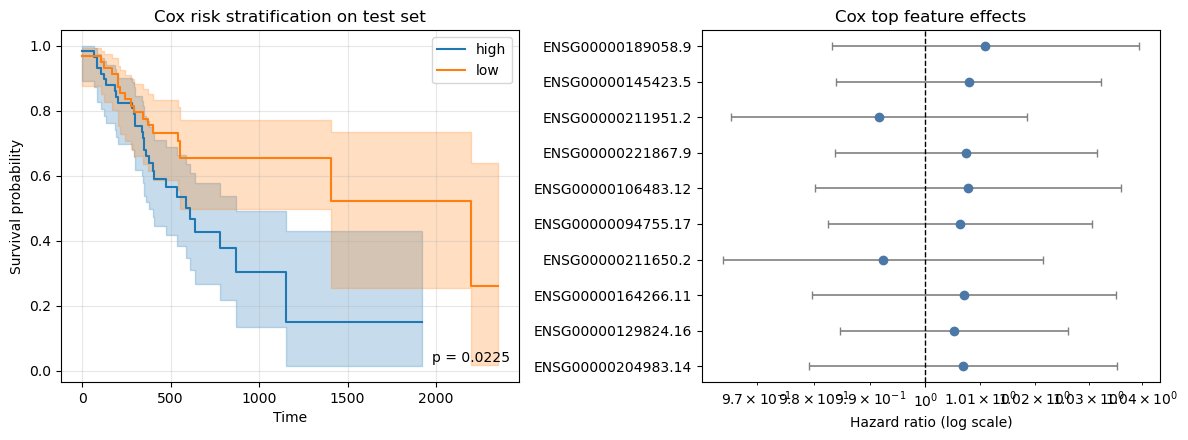

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_grouped_km_with_pvalue(cox_test, 'duration', 'event', 'risk_group', 'low', 'high', ax=axes[0])
axes[0].set_title('Cox risk stratification on test set')
plot_feature_importance(cox.hazard_ratios, ax=axes[1], top_n=10)
axes[1].set_title('Cox top feature effects')
plt.tight_layout()
plt.show()


## LASSO-Cox Model

We run LASSO-Cox separately and show its own plot right after training.

In [4]:
lasso = LassoCoxModel(penalizer=0.1, cv=5, random_state=42)
lasso.fit_cv(
    train_df,
    'duration',
    'event',
    penalizers=[1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0],
    n_repeats=3,
    use_one_se_rule=True,
)

lasso_train_c_index = lasso.score(train_df)
lasso_test_c_index = lasso.score(test_df)

lasso_test = test_df.copy()
lasso_test['risk_score'] = lasso.predict_risk_score(test_df).values
lasso_test['risk_group'] = split_risk_group(lasso_test['risk_score'])

print(f'LASSO train c-index: {lasso_train_c_index:.4f}')
print(f'LASSO test c-index:  {lasso_test_c_index:.4f}')
print('Selected penalizer:', lasso.penalizer)
print('Selected features:', len(lasso.selected_features))


/home/zengj/.conda/envs/survivalnet/lib/python3.14/site-packages/lifelines/fitters/coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(
/home/zengj/.conda/envs/survivalnet/lib/python3.14/site-packages/lifelines/fitters/coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(
/home/zengj/.conda/envs/survivalnet/lib/python3.14/site-packages/lifelines/fitters/coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.rea

LASSO train c-index: 0.6039
LASSO test c-index:  0.5794
Selected penalizer: 0.1
Selected features: 1


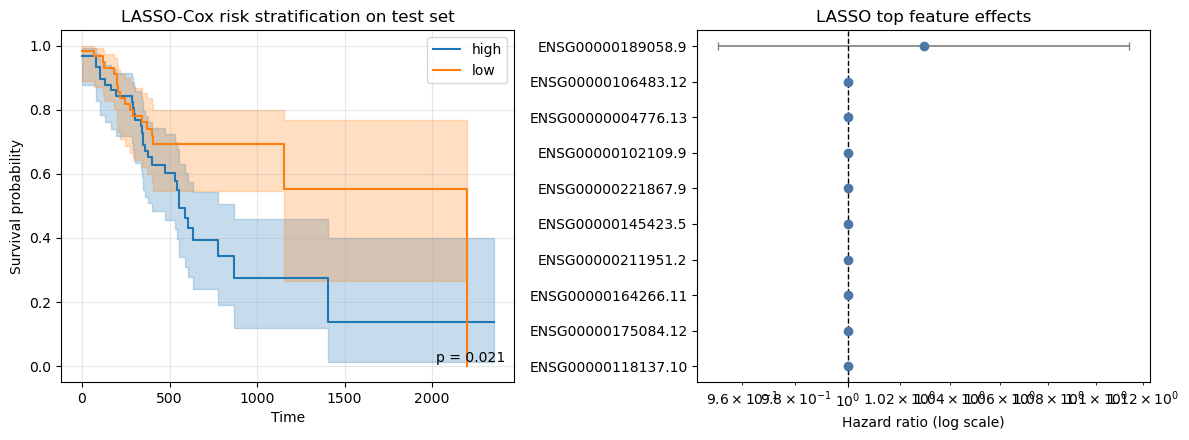

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_grouped_km_with_pvalue(lasso_test, 'duration', 'event', 'risk_group', 'low', 'high', ax=axes[0])
axes[0].set_title('LASSO-Cox risk stratification on test set')
plot_feature_importance(lasso.hazard_ratios, ax=axes[1], top_n=10)
axes[1].set_title('LASSO top feature effects')
plt.tight_layout()
plt.show()


## DeepSurv Model

DeepSurv is run separately as well, with a smaller network and model-specific preprocessing.

In [6]:
deep = DeepSurvModel(
    hidden_dim1=16,
    hidden_dim2=16,
    dropout=0.0,
    learning_rate=1e-3,
    batch_norm=True,
    batch_size=32,
    epochs=50,
    patience=8,
    validation_split=0.1,
    log_transform=True,
    max_features=120,
    min_expression_rate=0.05,
    random_state=42,
)
deep.fit(train_df, 'duration', 'event')

deep_train_c_index = deep.score(train_df)
deep_test_c_index = deep.score(test_df)

deep_test = test_df.copy()
deep_test['risk_score'] = deep.predict_risk_score(test_df).values
deep_test['risk_group'] = split_risk_group(deep_test['risk_score'])

print(f'DeepSurv train c-index: {deep_train_c_index:.4f}')
print(f'DeepSurv test c-index:  {deep_test_c_index:.4f}')
print('Number of parameters:', deep.n_parameters_)


DeepSurv train c-index: 0.4990
DeepSurv test c-index:  0.5419
Number of parameters: 2289


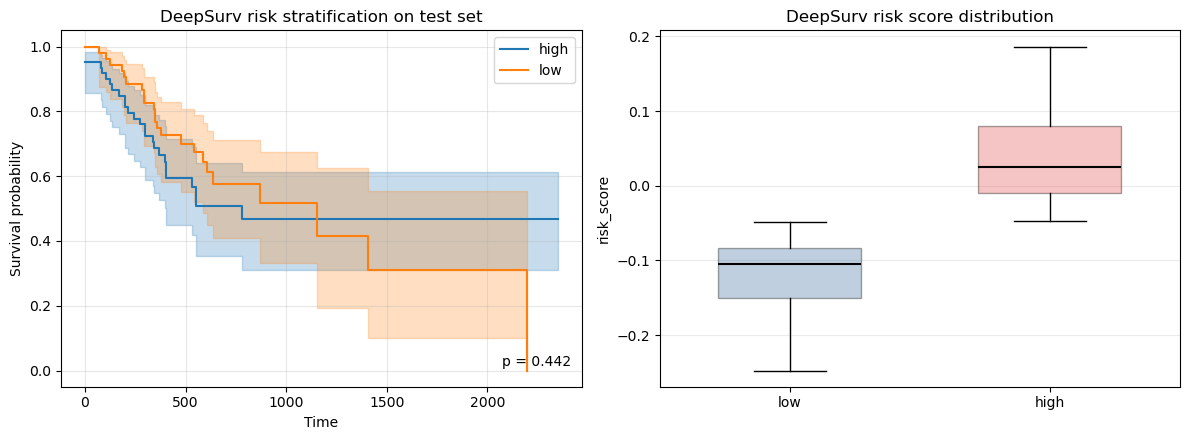

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_grouped_km_with_pvalue(deep_test, 'duration', 'event', 'risk_group', 'low', 'high', ax=axes[0])
axes[0].set_title('DeepSurv risk stratification on test set')
plot_risk_score_distribution(deep_test, 'risk_score', ax=axes[1])
axes[1].set_title('DeepSurv risk score distribution')
plt.tight_layout()
plt.show()


## Summary

We summarize the three models here and then show one combined comparison figure.

In [8]:
results = pd.DataFrame([
    {
        'model': 'cox',
        'train_c_index': cox_train_c_index,
        'test_c_index': cox_test_c_index,
        'selected_penalizer': cox.penalizer,
    },
    {
        'model': 'lasso',
        'train_c_index': lasso_train_c_index,
        'test_c_index': lasso_test_c_index,
        'selected_penalizer': lasso.penalizer,
    },
    {
        'model': 'deep',
        'train_c_index': deep_train_c_index,
        'test_c_index': deep_test_c_index,
        'selected_penalizer': None,
    },
])

results


,model,train_c_index,test_c_index,selected_penalizer
0,cox,0.719947,0.541921,3.0
1,lasso,0.603900,0.579400,0.1
2,deep,0.499025,0.541921,NaN


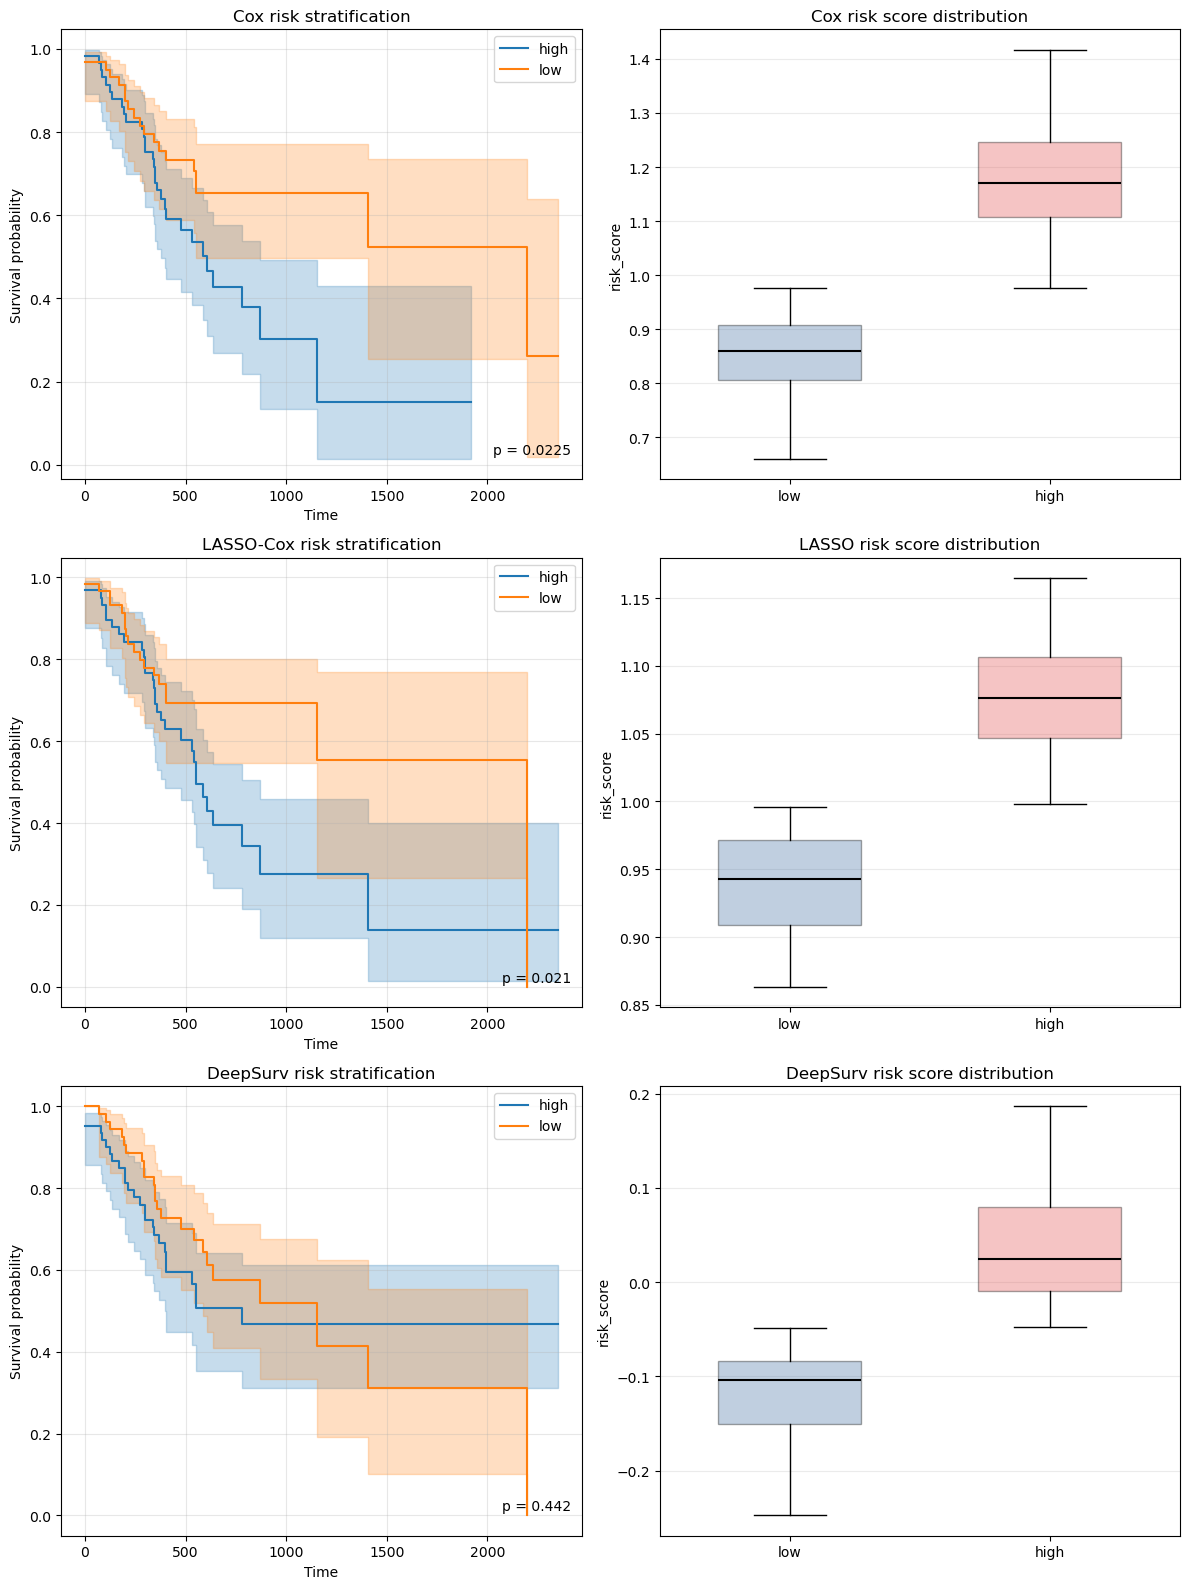

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(12, 16))

plot_grouped_km_with_pvalue(cox_test, 'duration', 'event', 'risk_group', 'low', 'high', ax=axes[0, 0])
axes[0, 0].set_title('Cox risk stratification')
plot_risk_score_distribution(cox_test, 'risk_score', ax=axes[0, 1])
axes[0, 1].set_title('Cox risk score distribution')

plot_grouped_km_with_pvalue(lasso_test, 'duration', 'event', 'risk_group', 'low', 'high', ax=axes[1, 0])
axes[1, 0].set_title('LASSO-Cox risk stratification')
plot_risk_score_distribution(lasso_test, 'risk_score', ax=axes[1, 1])
axes[1, 1].set_title('LASSO risk score distribution')

plot_grouped_km_with_pvalue(deep_test, 'duration', 'event', 'risk_group', 'low', 'high', ax=axes[2, 0])
axes[2, 0].set_title('DeepSurv risk stratification')
plot_risk_score_distribution(deep_test, 'risk_score', ax=axes[2, 1])
axes[2, 1].set_title('DeepSurv risk score distribution')

plt.tight_layout()
plt.show()
